In [48]:
import pandas as pd

df = pd.read_csv(r"C:\Users\MINA\Documents\WeekilyPrac\Ml_JOUNRAL\ml-learning-journal\Time Series\Datasets\AirPassengers.csv")

In [49]:
df.head()

,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [50]:
df.columns

Index(['Month', '#Passengers'], dtype='str')

In [51]:
df.dtypes

Month            str
#Passengers    int64
dtype: object

In [52]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Month        144 non-null    str  
 1   #Passengers  144 non-null    int64
dtypes: int64(1), str(1)
memory usage: 2.4 KB


In [53]:
df.describe()

,#Passengers
count,144.000000
mean,280.298611
std,119.966317
min,104.000000
25%,180.000000
50%,265.500000
75%,360.500000
max,622.000000


In [54]:
df.isnull().sum()

Month          0
#Passengers    0
dtype: int64

In [55]:
# df.set_index('Month', inplace=True)

In [56]:
df.index

RangeIndex(start=0, stop=144, step=1)

In [57]:
df = df.rename(columns={'#Passengers':"Passengers"})
df.columns

Index(['Month', 'Passengers'], dtype='str')

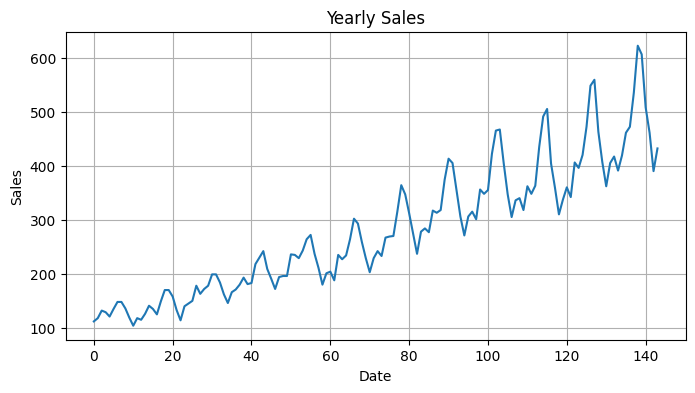

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.plot(df.index,df['Passengers'])
plt.title('Yearly Sales')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

#### check every month sales

In [59]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index(df['Month'],inplace=True)

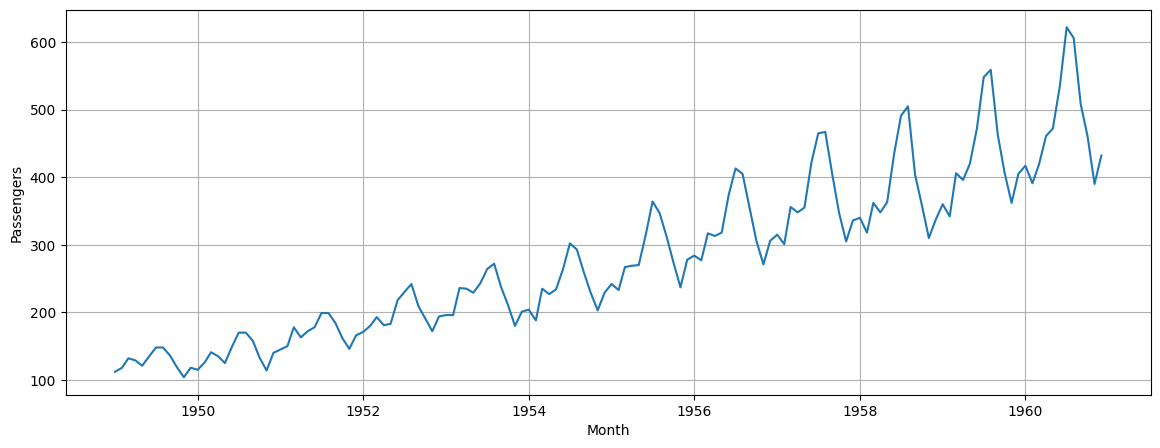

In [60]:
plt.figure(figsize=(14,5))
plt.plot(df.index,df['Passengers'])
plt.xlabel('Month')
plt.ylabel('Passengers')
plt.grid(True)
plt.show()

In [61]:
df['Month_Name'] = df.index.month_name()

monthly_avg = df.groupby('Month_Name')['Passengers'].mean()
print(monthly_avg)


Month_Name
April        267.083333
August       351.083333
December     261.833333
February     235.000000
January      241.750000
July         351.333333
June         311.666667
March        270.166667
May          271.833333
November     232.833333
October      266.583333
September    302.416667
Name: Passengers, dtype: float64


In [68]:
df.loc['1949']

,Month,Passengers,Month_Name
Month,,,
1949-01-01,1949-01-01,112,January
1949-02-01,1949-02-01,118,February
1949-03-01,1949-03-01,132,March
1949-04-01,1949-04-01,129,April
1949-05-01,1949-05-01,121,May
1949-06-01,1949-06-01,135,June
1949-07-01,1949-07-01,148,July
1949-08-01,1949-08-01,148,August
1949-09-01,1949-09-01,136,September


In [72]:
pd.to_datetime('2026-07-20').month_name()

'July'

In [73]:
month_avg = df.groupby('Month_Name')['Passengers'].mean()
print(month_avg)

Month_Name
April        267.083333
August       351.083333
December     261.833333
February     235.000000
January      241.750000
July         351.333333
June         311.666667
March        270.166667
May          271.833333
November     232.833333
October      266.583333
September    302.416667
Name: Passengers, dtype: float64


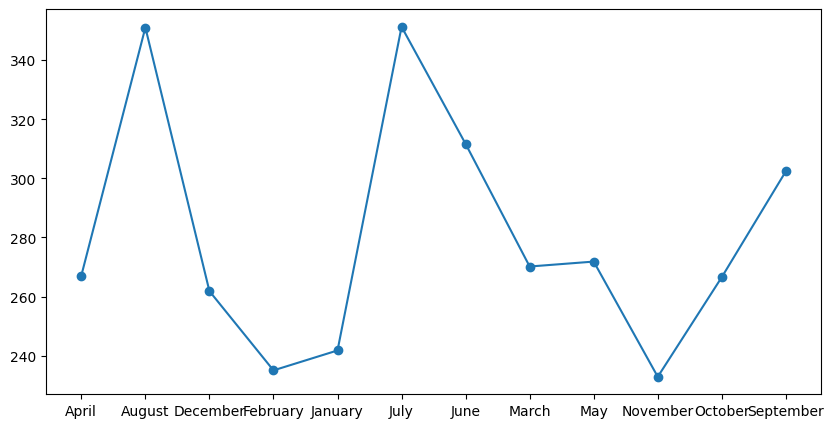

In [76]:
plt.figure(figsize=(10,5))

plt.plot(month_avg.index, month_avg.values,marker='o')
plt.show()

In [82]:
df['year_avg'] = df.index.year
yearly_avg = df.groupby('year_avg')['Passengers'].mean()
print(yearly_avg)

year_avg
1949    126.666667
1950    139.666667
1951    170.166667
1952    197.000000
1953    225.000000
1954    238.916667
1955    284.000000
1956    328.250000
1957    368.416667
1958    381.000000
1959    428.333333
1960    476.166667
Name: Passengers, dtype: float64


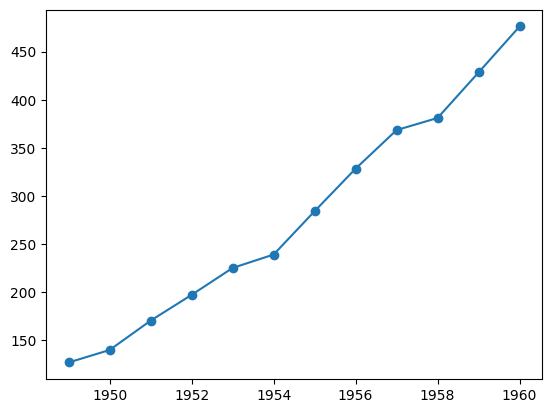

In [83]:
plt.plot(yearly_avg.index, yearly_avg.values,marker='o')
plt.show()

In [84]:
# Monthly Maximum
month_max = df.groupby('Month_Name')['Passengers'].max()
month_max

Month_Name
April        461
August       606
December     432
February     391
January      417
July         622
June         535
March        419
May          472
November     390
October      461
September    508
Name: Passengers, dtype: int64

In [86]:
month_count = df.groupby('Month_Name')['Passengers'].count()
month_count

Month_Name
April        12
August       12
December     12
February     12
January      12
July         12
June         12
March        12
May          12
November     12
October      12
September    12
Name: Passengers, dtype: int64

In [87]:
monthly_table = df.pivot_table(
    values='Passengers',
    index=df.index.year,
    columns=df.index.month_name()
)

print(monthly_table)

Month  April  August  December  February  January   July   June  March    May  \
Month                                                                           
1949   129.0   148.0     118.0     118.0    112.0  148.0  135.0  132.0  121.0   
1950   135.0   170.0     140.0     126.0    115.0  170.0  149.0  141.0  125.0   
1951   163.0   199.0     166.0     150.0    145.0  199.0  178.0  178.0  172.0   
1952   181.0   242.0     194.0     180.0    171.0  230.0  218.0  193.0  183.0   
1953   235.0   272.0     201.0     196.0    196.0  264.0  243.0  236.0  229.0   
1954   227.0   293.0     229.0     188.0    204.0  302.0  264.0  235.0  234.0   
1955   269.0   347.0     278.0     233.0    242.0  364.0  315.0  267.0  270.0   
1956   313.0   405.0     306.0     277.0    284.0  413.0  374.0  317.0  318.0   
1957   348.0   467.0     336.0     301.0    315.0  465.0  422.0  356.0  355.0   
1958   348.0   505.0     337.0     318.0    340.0  491.0  435.0  362.0  363.0   
1959   396.0   559.0     405

In [88]:
df['Monthly_Growth'] = df['Passengers'].diff()
df['Monthly_Growth']

Month
1949-01-01     NaN
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
              ... 
1960-08-01   -16.0
1960-09-01   -98.0
1960-10-01   -47.0
1960-11-01   -71.0
1960-12-01    42.0
Name: Monthly_Growth, Length: 144, dtype: float64

In [89]:
df.index.year

Index([1949, 1949, 1949, 1949, 1949, 1949, 1949, 1949, 1949, 1949,
       ...
       1960, 1960, 1960, 1960, 1960, 1960, 1960, 1960, 1960, 1960],
      dtype='int32', name='Month', length=144)

In [90]:
df['MA_3'] = df['Passengers'].rolling(3).mean()

df['MA_3']

Month
1949-01-01           NaN
1949-02-01           NaN
1949-03-01    120.666667
1949-04-01    126.333333
1949-05-01    127.333333
                 ...    
1960-08-01    587.666667
1960-09-01    578.666667
1960-10-01    525.000000
1960-11-01    453.000000
1960-12-01    427.666667
Name: MA_3, Length: 144, dtype: float64

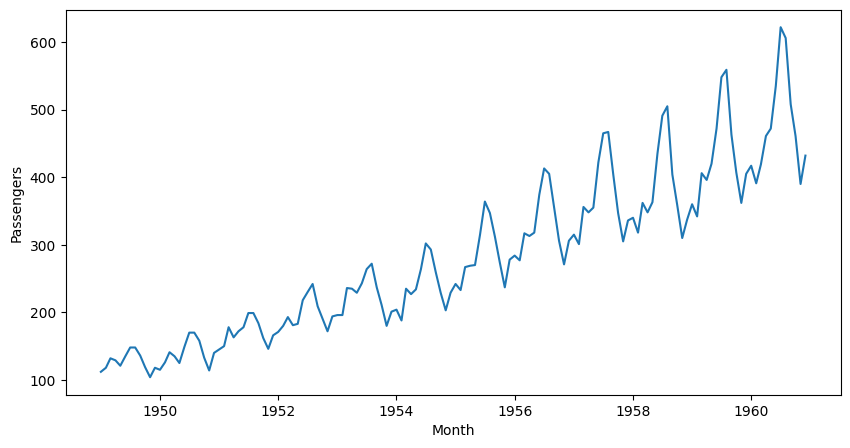

In [91]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.lineplot(x=df.index, y=df['Passengers'])
plt.show()

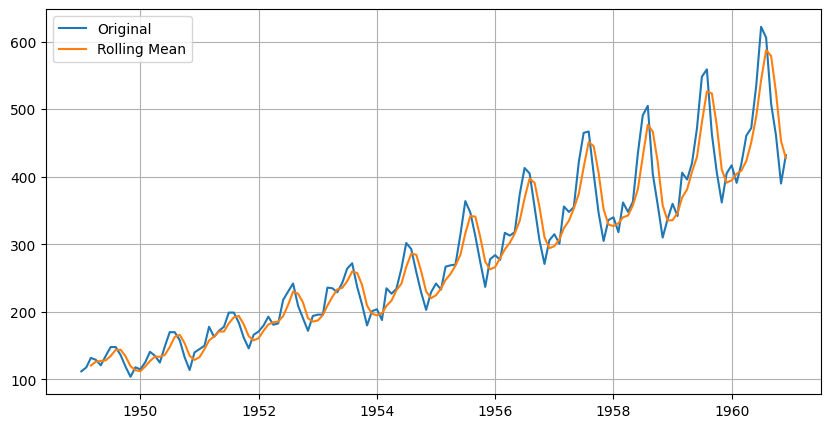

In [92]:
df["Rolling_Mean"] = df["Passengers"].rolling(window=3).mean()

plt.figure(figsize=(10,5))
plt.plot(df.index, df["Passengers"], label="Original")
plt.plot(df.index, df["Rolling_Mean"], label="Rolling Mean")
plt.legend()
plt.grid(True)
plt.show()